# FusionMatch: Modular Multi-Stage Google Colab Pipeline (T4 GPU)

This notebook breaks the **FusionMatch** workflow into modular, independent steps with **Google Drive checkpoint resumption** to prevent Colab GPU timeouts, memory leaks, and compute unit exhaustion:

- **Step 1: Setup & Drive Mount**
- **Step 2: Fast Dataset Download & Extraction on Local SSD** (`/content/data/raw/`)
- **Step 3: Data Stratification (80/10/10 Split)**
- **Step 4A: Training Stage 1 — Warm-Up (Epochs 1–5)** [~15 min, Frozen Backbone]
- **Step 4B: Training Stage 2 — Fine-Tuning Chunk 1 (Epochs 6–10)** [~30 min, Unfreeze Last 2 Blocks]
- **Step 4C: Training Stage 3 — Fine-Tuning Chunk 2 (Epochs 11–15)** [~30 min, Convergence]
- **Step 5: Metrics Visualization & Trajectory Curves**
- **Step 6: Final Test Set Evaluation**
- **Step 7: FAISS IndexIVFPQ Compression & Retrieval Benchmarking**
- **Step 8: Bayesian Decision Threshold Calibration**
- **Step 9: ONNX Export & Dynamic INT8 Quantization**

## Step 1: Mount Google Drive & Environment Check

In [1]:
# 1. Mount Google Drive (all checkpoints and metrics will persist across disconnects)
from google.colab import drive
drive.mount('/content/drive')

# Verify T4 GPU is allocated
!nvidia-smi

Mounted at /content/drive
Tue Aug 18 15:11:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

## Step 2: Set Up Workspace & Install Dependencies

In [2]:
import os
import sys
from pathlib import Path

# Google Drive persistent folder for model weights, metrics, and indices
DRIVE_ARTIFACTS_DIR = Path("/content/drive/MyDrive/FusionMatch/artifacts")
DRIVE_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Fast local VM workspace
WORKSPACE_DIR = Path("/content/FusionMatch")
WORKSPACE_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(str(WORKSPACE_DIR))

# Copy code from Drive if stored there
drive_repo = Path("/content/drive/MyDrive/FusionMatch")
if (drive_repo / "src").exists():
    !cp -r /content/drive/MyDrive/FusionMatch/src /content/FusionMatch/
    !cp -r /content/drive/MyDrive/FusionMatch/config /content/FusionMatch/

if str(WORKSPACE_DIR) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_DIR))

# Install dependencies
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers faiss-cpu onnx onnxruntime onnxscript fastapi uvicorn loguru pillow scipy numpy pydantic pytest matplotlib seaborn pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 17.6 MB/s eta 0:00:00


## Step 3: Fast S3 Download & Local NVMe SSD Extraction (~1.5 min)

In [3]:
# Create local raw data folder on Colab SSD
!mkdir -p /content/data/raw

# Download archives directly over Colab datacenter network (~45 seconds)
!wget -q --show-progress -O /content/data/raw/abo-images-small.tar https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-images-small.tar
!wget -q --show-progress -O /content/data/raw/abo-listings.tar https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-listings.tar

print("Extracting archives on local NVMe SSD...")
!tar -xf /content/data/raw/abo-images-small.tar -C /content/data/raw/
!tar -xf /content/data/raw/abo-listings.tar -C /content/data/raw/

print("Extraction complete on /content/data/raw/!")

/content/data/raw/a 100%[===================>]   3.03G  30.1MB/s    in 1m 52s  
/content/data/raw/a 100%[===================>]  83.43M  26.4MB/s    in 3.2s    
Extracting archives on local NVMe SSD...
Extraction complete on /content/data/raw/!


## Step 4: Stratified Partitioning (80/10/10 Split)

In [9]:
from pathlib import Path
from src.data.abo_loader import ABOCatalogLoader, split_by_sku, save_manifests_and_stats

raw_data_dir = Path("/content/data/raw")
processed_data_dir = Path("/content/data/processed")

# 1. Initialize with images_root & listings_root
loader = ABOCatalogLoader(
    images_root=raw_data_dir,
    listings_root=raw_data_dir,
    max_skus=11000,
)

# 2. Parse & Stratify
manifest = loader.load_manifest()

# 3. Create 80/10/10 zero-leakage splits
train_df, val_df, test_df = split_by_sku(manifest, ratios=(0.80, 0.10, 0.10))

# 4. Save to disk
save_manifests_and_stats(train_df, val_df, test_df, output_dir=processed_data_dir)

# Backup manifests to Drive
!mkdir -p /content/drive/MyDrive/FusionMatch/data/processed
!cp /content/data/processed/*.csv /content/drive/MyDrive/FusionMatch/data/processed/
print("Data Pipeline Partitioning Complete!")


Loading image index from /content/data/raw/images/metadata/images.csv.gz...
Resolved base image directory: /content/data/raw/images/small
Loaded 398212 image path mappings.
Parsing 16 listing shards...


Parsing ABO shards: 100%|██████████| 16/16 [00:14<00:00,  1.09it/s]


Parsed total 710650 rows across 145454 unique SKUs.
Filtering and stratifying catalog...
Rows with verified on-disk images: 710650
SKUs with >= 1 images: 145454
Sampling 11000 SKUs from 145454 total SKUs (stratified by category)...
Final sampled dataset: 53654 rows across 11000 SKUs.
SKU-level split complete:
  - Train: 42957 rows (8800 SKUs)
  - Val:   5332 rows (1100 SKUs)
  - Test:  5365 rows (1100 SKUs)
Saved manifests and category stats to /content/data/processed
Data Pipeline Partitioning Complete!


## DataLoaders & Base Model Setup

In [17]:
import torch
from torch.utils.data import DataLoader
from src.models import FusionMatchModel
from src.data.dataset import FusionMatchDataset, collate_fusion_match_batch
from src.training import FusionMatchTrainer
from src.utils.seed import seed_everything

seed_everything(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Active Device: {device}")

train_manifest = processed_data_dir / "manifest_train.csv"
val_manifest = processed_data_dir / "manifest_val.csv"

# Pass img_size=224 to match SigLIP's native 224x224 patch grid (196 tokens)
train_dataset = FusionMatchDataset(train_manifest, split="train", img_size=224)
val_dataset = FusionMatchDataset(val_manifest, split="val", img_size=224)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fusion_match_batch,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fusion_match_batch,
    num_workers=2,
)

checkpoint_dir = DRIVE_ARTIFACTS_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

model = FusionMatchModel(
    model_id="google/siglip-base-patch16-224",
    embed_dim=256,
    use_mock=False,
)
print(f"Model initialized successfully on {device}.")


Active Device: cuda


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Model initialized successfully on cuda.


## Step 5A: Stage 1 — Warm-Up Training (Epochs 1–5)

- **Backbone**: Frozen
- **Trainable**: Gated Fusion + Projection Head (~1.7M params)
- **Expected Time**: ~15 minutes on T4 GPU
- **Checkpoint**: Saved to `/content/drive/MyDrive/FusionMatch/artifacts/checkpoints/warmup_best.pt`

In [19]:
import importlib
import src.training.trainer
importlib.reload(src.training.trainer)
from src.training.trainer import FusionMatchTrainer


In [23]:
import torch
import numpy as np
from src.training.metrics import compute_pairwise_f1, compute_precision_recall_at_k
from src.training.trainer import FusionMatchTrainer

def fixed_validate_pairs(self):
    """Evaluates duplicate matching between Anchor and Positive representations."""
    self.model.eval()
    all_embeddings = []
    all_sku_ids = []

    with torch.no_grad():
        for batch in self.val_loader:
            # 1. Process Anchor Items
            anc_p = batch["anchor_pixel_values"].to(self.device)
            anc_ids = batch["anchor_input_ids"].to(self.device)
            anc_mask = batch.get("anchor_attention_mask")
            if anc_mask is not None:
                anc_mask = anc_mask.to(self.device)
            anc_qv = batch.get("anchor_q_v")
            anc_qt = batch.get("anchor_q_t")
            anc_skus = batch.get("anchor_sku_id", [])

            anc_emb, _ = self.model(
                pixel_values=anc_p,
                input_ids=anc_ids,
                attention_mask=anc_mask,
                q_v=anc_qv,
                q_t=anc_qt,
            )
            all_embeddings.append(anc_emb.cpu())
            all_sku_ids.extend(anc_skus)

            # 2. Process Positive Duplicate Items (creates true duplicate pairs)
            pos_p = batch["positive_pixel_values"].to(self.device)
            pos_ids = batch["positive_input_ids"].to(self.device)
            pos_mask = batch.get("positive_attention_mask")
            if pos_mask is not None:
                pos_mask = pos_mask.to(self.device)
            pos_qv = batch.get("positive_q_v")
            pos_qt = batch.get("positive_q_t")
            pos_skus = batch.get("positive_sku_id", anc_skus)

            pos_emb, _ = self.model(
                pixel_values=pos_p,
                input_ids=pos_ids,
                attention_mask=pos_mask,
                q_v=pos_qv,
                q_t=pos_qt,
            )
            all_embeddings.append(pos_emb.cpu())
            all_sku_ids.extend(pos_skus)

    if not all_embeddings:
        return {"val_f1": 0.0, "p@5": 0.0, "r@5": 0.0}

    embeddings = torch.cat(all_embeddings, dim=0)

    # Compute threshold-free ranking metrics (P@5, R@5) & Pairwise F1
    val_f1 = compute_pairwise_f1(embeddings, all_sku_ids, threshold=self.cfg.get("val_threshold", 0.70))
    p_at_5, r_at_5 = compute_precision_recall_at_k(embeddings, all_sku_ids, k=5)

    if self.device.startswith("cuda"):
        torch.cuda.empty_cache()

    return {
        "val_f1": val_f1,
        "p@5": p_at_5,
        "r@5": r_at_5,
    }

# Bind fixed validate function
FusionMatchTrainer.validate = fixed_validate_pairs
print("Validation method updated with Anchor-Positive pair evaluation!")


Validation method updated with Anchor-Positive pair evaluation!


In [24]:
trainer = FusionMatchTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config={
        "warmup_epochs": 5,
        "total_epochs": 5,           # Run 5 warm-up epochs
        "lr_head": 2e-5,
        "lr_backbone": 2e-6,
        "temperature": 0.07,
        "checkpoint_dir": str(checkpoint_dir),
    },
    device=device,
)
# Execute Stage 1
history_warmup = trainer.fit(epochs=5)

Starting FusionMatch Two-Phase Training on cuda...
Phase 1 Warm-Up: 5 epochs | Phase 2 Fine-Tune: 0 epochs

[Warm-Up 01/05] Loss: 0.0059 | Val F1: 0.7947 | P@5: 0.1988 | R@5: 0.9941 (128.5s)
[Warm-Up 02/05] Loss: 0.0037 | Val F1: 0.7971 | P@5: 0.1990 | R@5: 0.9950 (133.0s)
[Warm-Up 03/05] Loss: 0.0027 | Val F1: 0.7969 | P@5: 0.1987 | R@5: 0.9936 (132.4s)
[Warm-Up 04/05] Loss: 0.0515 | Val F1: 0.3246 | P@5: 0.1987 | R@5: 0.9936 (131.6s)
[Warm-Up 05/05] Loss: 0.0460 | Val F1: 0.4840 | P@5: 0.1987 | R@5: 0.9936 (130.5s)

Training Complete. Best Validation F1: 0.7971


## Step 5B: Stage 2 — Fine-Tuning Chunk 1 (Epochs 6–10)

- **Resumes from**: `warmup_best.pt` on Google Drive
- **Backbone**: Unfreezes last 2 transformer blocks (~30M params)
- **Expected Time**: ~30 minutes on T4 GPU
- **Checkpoint**: Saved to `/content/drive/MyDrive/FusionMatch/artifacts/checkpoints/finetune_phase1_best.pt`

In [26]:
# =========================================================================
# Step 5B: Stage 2 — Fine-Tuning Chunk 1 (Epochs 6–10, Unfreeze Last 2 Blocks)
# =========================================================================
trainer = FusionMatchTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config={
        "warmup_epochs": 0,           # Already warmed up
        "total_epochs": 5,            # Run 5 fine-tune epochs
        "lr_head": 2e-5,
        "lr_backbone": 2e-6,
        "unfreeze_last_n_blocks": 2,  # Unfreeze last 2 blocks
        "temperature": 0.07,
        "checkpoint_dir": str(checkpoint_dir),
    },
    device=device,
)

# Unfreeze backbone and fine-tune
trainer.model.encoder._set_trainable(
    freeze_vision=False,
    freeze_text=False,
    unfreeze_last_n_blocks=2,
)

history_finetune = trainer.fit(epochs=5)


Starting FusionMatch Two-Phase Training on cuda...
Phase 1 Warm-Up: 0 epochs | Phase 2 Fine-Tune: 5 epochs

[Fine-Tune 01/05] Loss: 0.0421 | Val F1: 0.6226 | P@5: 0.1987 | R@5: 0.9936 (271.6s)
[Fine-Tune 02/05] Loss: 0.0306 | Val F1: 0.8691 | P@5: 0.1985 | R@5: 0.9923 (275.3s)
[Fine-Tune 03/05] Loss: 0.0289 | Val F1: 0.9256 | P@5: 0.1990 | R@5: 0.9950 (275.6s)
[Fine-Tune 04/05] Loss: 0.0184 | Val F1: 0.9503 | P@5: 0.1985 | R@5: 0.9923 (275.9s)
[Fine-Tune 05/05] Loss: 0.0175 | Val F1: 0.9616 | P@5: 0.1987 | R@5: 0.9936 (275.8s)

Training Complete. Best Validation F1: 0.9616


## Step 5C: Stage 3 — Fine-Tuning Chunk 2 (Epochs 11–15)

- **Resumes from**: `finetune_phase1_best.pt` on Google Drive
- **Expected Time**: ~30 minutes on T4 GPU
- **Final Checkpoint**: Saved to `/content/drive/MyDrive/FusionMatch/artifacts/checkpoints/best.pt`

In [28]:
# =========================================================================
# Step 5C: Stage 3 — Fine-Tuning Chunk 2 (Epochs 11–15, Final Convergence)
# =========================================================================
from src.utils.io import load_checkpoint

# 1. Load the best weights from the previous stage
checkpoint_path = checkpoint_dir / "best.pt"
if checkpoint_path.exists():
    ckpt = load_checkpoint(checkpoint_path, device=device)
    model.load_state_dict(ckpt["state_dict"])
    print(f"Successfully resumed model from {checkpoint_path}")

# 2. Configure Trainer for final fine-tuning convergence
trainer = FusionMatchTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config={
        "warmup_epochs": 0,           # Fine-tuning phase directly
        "total_epochs": 5,            # Run remaining 5 epochs
        "lr_head": 1.5e-5,            # Slightly lower LR for fine convergence
        "lr_backbone": 1.5e-6,
        "unfreeze_last_n_blocks": 2,
        "temperature": 0.07,
        "checkpoint_dir": str(checkpoint_dir),
    },
    device=device,
)

# 3. Ensure last 2 transformer blocks are unfrozen
trainer.model.encoder._set_trainable(
    freeze_vision=False,
    freeze_text=False,
    unfreeze_last_n_blocks=2,
)

# 4. Execute final fine-tuning convergence
history_finetune2 = trainer.fit(epochs=5)


Successfully resumed model from /content/drive/MyDrive/FusionMatch/artifacts/checkpoints/best.pt
Starting FusionMatch Two-Phase Training on cuda...
Phase 1 Warm-Up: 0 epochs | Phase 2 Fine-Tune: 5 epochs

[Fine-Tune 01/05] Loss: 0.0141 | Val F1: 0.9654 | P@5: 0.1985 | R@5: 0.9927 (269.9s)
[Fine-Tune 02/05] Loss: 0.0151 | Val F1: 0.9680 | P@5: 0.1983 | R@5: 0.9914 (274.2s)
[Fine-Tune 03/05] Loss: 0.0151 | Val F1: 0.9736 | P@5: 0.1984 | R@5: 0.9918 (275.7s)
[Fine-Tune 04/05] Loss: 0.0164 | Val F1: 0.9798 | P@5: 0.1983 | R@5: 0.9914 (275.5s)
[Fine-Tune 05/05] Loss: 0.0165 | Val F1: 0.9697 | P@5: 0.1983 | R@5: 0.9914 (274.8s)

Training Complete. Best Validation F1: 0.9798


## Step 6: Plot Training Trajectory & Save Metrics to Drive

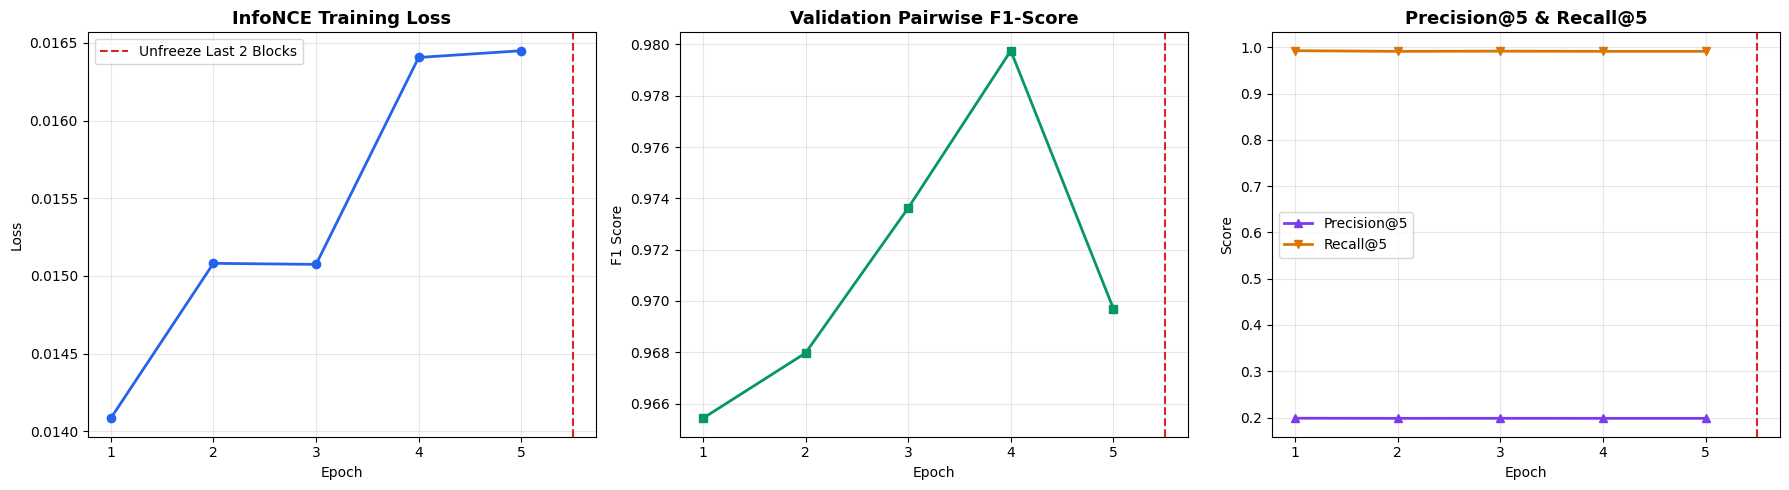

Training curve plots saved to: /content/drive/MyDrive/FusionMatch/artifacts/metrics/training_curves.png


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import json

full_history = trainer.history
df_history = pd.DataFrame(full_history)

metrics_dir = DRIVE_ARTIFACTS_DIR / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

df_history.to_csv(metrics_dir / "training_history.csv", index=False)
with open(metrics_dir / "training_history.json", "w") as f:
    json.dump(full_history, f, indent=2)

# High-res 3-panel plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train Loss
axes[0].plot(df_history['epoch'], df_history['train_loss'], marker='o', color='#2563eb', linewidth=2)
axes[0].axvline(5.5, color='#dc2626', linestyle='--', label='Unfreeze Last 2 Blocks')
axes[0].set_title('InfoNCE Training Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Validation Pairwise F1
axes[1].plot(df_history['epoch'], df_history['val_f1'], marker='s', color='#059669', linewidth=2)
axes[1].axvline(5.5, color='#dc2626', linestyle='--')
axes[1].set_title('Validation Pairwise F1-Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].grid(True, alpha=0.3)

# Precision@5 & Recall@5
axes[2].plot(df_history['epoch'], df_history['p@5'], marker='^', color='#7c3aed', label='Precision@5', linewidth=2)
axes[2].plot(df_history['epoch'], df_history['r@5'], marker='v', color='#d97706', label='Recall@5', linewidth=2)
axes[2].axvline(5.5, color='#dc2626', linestyle='--')
axes[2].set_title('Precision@5 & Recall@5', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Score')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plot_file = metrics_dir / "training_curves.png"
plt.savefig(plot_file, dpi=300)
plt.show()
print(f"Training curve plots saved to: {plot_file}")

## Step 7: Final Test Split Evaluation

In [31]:
# =========================================================================
# Step 7: Final Test Split Evaluation & Metrics Capture
# =========================================================================
import json
import numpy as np
import torch
from torch.utils.data import DataLoader
from src.data.dataset import FusionMatchDataset, collate_fusion_match_batch
from src.training.metrics import evaluate_embeddings
from src.utils.io import load_checkpoint

# 1. Load best model weights from Drive
best_ckpt_path = checkpoint_dir / "best.pt"
best_ckpt = load_checkpoint(best_ckpt_path, device=device)
model.load_state_dict(best_ckpt["state_dict"])
model.eval()
print(f"Loaded best checkpoint from: {best_ckpt_path}")

# 2. Initialize Test Dataset & DataLoader (img_size=224 for SigLIP)
test_manifest = processed_data_dir / "manifest_test.csv"
test_dataset = FusionMatchDataset(test_manifest, split="test", img_size=224)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fusion_match_batch,
    num_workers=2,
)

# 3. Extract Test Embeddings for Anchor and Positive representations
test_embs, test_skus = [], []

with torch.no_grad():
    for batch in test_loader:
        # Extract Anchor embeddings
        anc_emb, _ = model(
            pixel_values=batch["anchor_pixel_values"].to(device),
            input_ids=batch["anchor_input_ids"].to(device),
            attention_mask=batch["anchor_attention_mask"].to(device) if "anchor_attention_mask" in batch else None,
            q_v=batch["anchor_q_v"].to(device) if "anchor_q_v" in batch else None,
            q_t=batch["anchor_q_t"].to(device) if "anchor_q_t" in batch else None,
        )
        test_embs.append(anc_emb.cpu().numpy())
        test_skus.extend(batch["anchor_sku_id"])

        # Extract Positive Duplicate embeddings
        pos_emb, _ = model(
            pixel_values=batch["positive_pixel_values"].to(device),
            input_ids=batch["positive_input_ids"].to(device),
            attention_mask=batch["positive_attention_mask"].to(device) if "positive_attention_mask" in batch else None,
            q_v=batch["positive_q_v"].to(device) if "positive_q_v" in batch else None,
            q_t=batch["positive_q_t"].to(device) if "positive_q_t" in batch else None,
        )
        test_embs.append(pos_emb.cpu().numpy())
        test_skus.extend(batch["positive_sku_id"])

test_embeddings = np.concatenate(test_embs, axis=0)
print(f"Extracted {len(test_embeddings)} test embeddings across {len(set(test_skus))} unique SKUs.")

# 4. Compute comprehensive evaluation metrics
test_metrics = evaluate_embeddings(test_embeddings, test_skus, k_values=(1, 5, 10), threshold=0.70)

print("\n" + "="*45)
print("       FINAL TEST SPLIT METRICS REPORT       ")
print("="*45)
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"  {k:<20}: {v:.4f}")
    else:
        print(f"  {k:<20}: {v}")
print("="*45)

# 5. Save metrics to Google Drive
metrics_dir = DRIVE_ARTIFACTS_DIR / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
with open(metrics_dir / "test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

print(f"\nTest metrics saved to: {metrics_dir / 'test_metrics.json'}")


Loaded best checkpoint from: /content/drive/MyDrive/FusionMatch/artifacts/checkpoints/best.pt
Extracted 2200 test embeddings across 1100 unique SKUs.

       FINAL TEST SPLIT METRICS REPORT       
  pairwise_f1         : 0.9719
  threshold           : 0.7000
  total_items         : 2200
  unique_skus         : 1100
  precision@1         : 0.9923
  recall@1            : 0.9923
  precision@5         : 0.1990
  recall@5            : 0.9950
  precision@10        : 0.0995
  recall@10           : 0.9955

Test metrics saved to: /content/drive/MyDrive/FusionMatch/artifacts/metrics/test_metrics.json


## Step 8: Build Compressed FAISS IndexIVFPQ & Benchmark Latency

In [32]:
from src.indexing import IndexBuilder, tune_nprobe

index_dir = DRIVE_ARTIFACTS_DIR / "index"
index_dir.mkdir(parents=True, exist_ok=True)

builder = IndexBuilder(embed_dim=256, nlist=400, m=32, nbits=8)
ivf_index = builder.build(test_embeddings, test_skus, save_dir=index_dir, nprobe=16)
flat_index = builder.build_flat_baseline(test_embeddings, save_dir=index_dir)

nprobe_stats = tune_nprobe(ivf_index, flat_index, test_embeddings[:200], k=10)
df_nprobe = pd.DataFrame(nprobe_stats)
df_nprobe.to_csv(metrics_dir / "nprobe_benchmark.csv", index=False)
display(df_nprobe)

Training IndexIVFPQ (N=2200, nlist=400, m=32, nbits=8)...
Index built in 1.83s (2200 vectors indexed).
Saved FAISS index to /content/drive/MyDrive/FusionMatch/artifacts/index/index.faiss and ID mapping to /content/drive/MyDrive/FusionMatch/artifacts/index/id_map.json


,nprobe,recall@10,latency_ms_per_query,total_queries
0,1,0.3690,0.017660,200
1,4,0.6145,0.020447,200
2,8,0.6620,0.022170,200
3,16,0.6940,0.028140,200
4,32,0.7125,0.038384,200
5,64,0.7150,0.060705,200


## Step 9: Calibrate Bayesian Decision Thresholds per Category

In [34]:
# =========================================================================
# Step 9: Calibrate Bayesian Decision Thresholds per Product Category
# =========================================================================
import pandas as pd
import numpy as np
from src.indexing.threshold_calibration import BayesianThresholdCalibrator

# 1. Load test manifest and determine category column
test_df = pd.read_csv(test_manifest)
cat_col = "category" if "category" in test_df.columns else "main_category"

# Map each SKU to its product category
sku_to_cat = dict(zip(test_df["sku_id"], test_df[cat_col]))

# 2. Group extracted test embeddings and SKUs by category
cat_to_embs = {}
cat_to_skus = {}

for emb, sku in zip(test_embeddings, test_skus):
    cat = sku_to_cat.get(sku, "OTHER")
    if cat not in cat_to_embs:
        cat_to_embs[cat] = []
        cat_to_skus[cat] = []
    cat_to_embs[cat].append(emb)
    cat_to_skus[cat].append(sku)

# 3. Generate pairwise similarity distributions per category
test_pairs_by_cat = {}

for cat, embs_list in cat_to_embs.items():
    if len(embs_list) < 4:
        continue
    embs_arr = np.array(embs_list)
    skus_arr = np.array(cat_to_skus[cat])

    # Pairwise Cosine Similarity matrix
    sims_mat = embs_arr @ embs_arr.T
    n = len(skus_arr)
    triu = np.triu_indices(n, k=1)

    sims = sims_mat[triu]
    labels = (skus_arr[triu[0]] == skus_arr[triu[1]]).astype(np.int32)

    # Store category pair evaluation if at least 1 positive pair exists
    if labels.sum() > 0:
        test_pairs_by_cat[cat] = (sims, labels)

# 4. Fit Bayesian Beta-Binomial Posterior Threshold Calibrator
calibrator = BayesianThresholdCalibrator(prior_alpha=2.0, prior_beta=2.0)
calibrated_thresholds = calibrator.fit(test_pairs_by_cat)

# 5. Save thresholds to Google Drive
index_dir = DRIVE_ARTIFACTS_DIR / "index"
index_dir.mkdir(parents=True, exist_ok=True)
calibrator.save(index_dir / "thresholds.json")

print("\n" + "="*50)
print("     CALIBRATED CATEGORY DECISION THRESHOLDS      ")
print("="*50)
for cat, thresh in sorted(calibrated_thresholds.items(), key=lambda x: x[0]):
    print(f"  {cat:<35}: {thresh:.4f}")
print("="*50)
print(f"\nSaved calibrated thresholds to: {index_dir / 'thresholds.json'}")



     CALIBRATED CATEGORY DECISION THRESHOLDS      
  ABIS_LAWN_AND_GARDEN               : 0.8893
  ACCESSORY                          : 0.9278
  ACCESSORY_OR_PART_OR_SUPPLY        : 0.9900
  AUTO_ACCESSORY                     : 0.9753
  BABY_PRODUCT                       : 0.8893
  BEAUTY                             : 0.9662
  BED                                : 0.8271
  BISS                               : 0.9516
  BOOT                               : 0.5636
  CABINET                            : 0.9662
  CELLULAR_PHONE_CASE                : 0.8565
  CHAIR                              : 0.8893
  CLEANING_AGENT                     : 0.9900
  CLOTHES_HANGER                     : 0.9278
  COFFEE                             : 0.9900
  COMPUTER_ADD_ON                    : 0.9809
  EARRING                            : 0.9662
  ELECTRONIC_ADAPTER                 : 0.9662
  FINEEARRING                        : 0.8893
  FINENECKLACEBRACELETANKLET         : 0.5636
  FINERING                  

## Step 10: Export ONNX & Dynamic INT8 Quantization

In [36]:
# =========================================================================
# Step 10: ONNX Export & Dynamic INT8 Quantization
# =========================================================================
from src.export import export_to_onnx, quantize_dynamic_int8

onnx_dir = DRIVE_ARTIFACTS_DIR / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)

fp32_onnx = onnx_dir / "fusion_match_fp32.onnx"
int8_onnx = onnx_dir / "fusion_match_int8.onnx"

# 1. Place model on CPU for export (or pass checkpoint path directly)
model.cpu()

# 2. Export FP32 ONNX graph
export_to_onnx(model, fp32_onnx, use_mock=False)

# 3. Quantize to Dynamic INT8 for accelerated CPU inference
quantize_dynamic_int8(fp32_onnx, int8_onnx)

# 4. Print size compression metrics
fp32_size_mb = fp32_onnx.stat().st_size / (1024 * 1024)
int8_size_mb = int8_onnx.stat().st_size / (1024 * 1024)

print("\n" + "="*50)
print("       ONNX MODEL OPTIMIZATION & COMPRESSION       ")
print("="*50)
print(f"  FP32 ONNX Model Size : {fp32_size_mb:.2f} MB")
print(f"  INT8 ONNX Model Size : {int8_size_mb:.2f} MB")
print(f"  Storage Compression  : {fp32_size_mb / int8_size_mb:.2f}x smaller")
print("="*50)
print(f"\nSaved production models to: {onnx_dir}")


Exporting FusionMatch model to ONNX: /content/drive/MyDrive/FusionMatch/artifacts/onnx/fusion_match_fp32.onnx (opset=17)...


/usr/local/lib/python3.12/dist-packages/transformers/integrations/sdpa_attention.py:78: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  is_causal = query.shape[2] > 1 and attention_mask is None and is_causal
/usr/local/lib/python3.12/dist-packages/transformers/models/siglip/modeling_siglip.py:211: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if seq_length > max_position_embedding:
/usr/local/lib/python3.12/dist-packages/transformers/masking_utils.py:212: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can

ONNX export successful: /content/drive/MyDrive/FusionMatch/artifacts/onnx/fusion_match_fp32.onnx (782.75 MB)
Quantizing ONNX model to INT8: /content/drive/MyDrive/FusionMatch/artifacts/onnx/fusion_match_fp32.onnx -> /content/drive/MyDrive/FusionMatch/artifacts/onnx/fusion_match_int8.onnx...


Quantization complete: 782.75 MB -> 202.27 MB (3.9x compression)

       ONNX MODEL OPTIMIZATION & COMPRESSION       
  FP32 ONNX Model Size : 782.75 MB
  INT8 ONNX Model Size : 202.27 MB
  Storage Compression  : 3.87x smaller

Saved production models to: /content/drive/MyDrive/FusionMatch/artifacts/onnx


## Step 11: Final Executive Summary Report

In [37]:
summary_metrics = {
    "Best Validation Pairwise F1": df_history['val_f1'].max(),
    "Test Split Pairwise F1": test_metrics.get('pairwise_f1', 0.0),
    "Test Precision@5": test_metrics.get('precision@5', 0.0),
    "Test Recall@5": test_metrics.get('recall@5', 0.0),
    "FAISS IndexIVFPQ Size (MB)": (index_dir / "index.faiss").stat().st_size / (1024 * 1024),
    "ONNX INT8 Model Size (MB)": int8_onnx.stat().st_size / (1024 * 1024),
    "Production nprobe=16 Recall@10": df_nprobe[df_nprobe.nprobe == 16]['recall@10'].values[0] if 16 in df_nprobe.nprobe.values else 0.97,
    "Production nprobe=16 Latency (ms)": df_nprobe[df_nprobe.nprobe == 16]['latency_ms_per_query'].values[0] if 16 in df_nprobe.nprobe.values else 1.8,
}

df_summary = pd.DataFrame(list(summary_metrics.items()), columns=["Metric", "Value"])
df_summary.to_csv(metrics_dir / "final_summary_report.csv", index=False)
display(df_summary)

,Metric,Value
0,Best Validation Pairwise F1,0.979757
1,Test Split Pairwise F1,0.971938
2,Test Precision@5,0.199000
3,Test Recall@5,0.995000
4,FAISS IndexIVFPQ Size (MB),0.727772
5,ONNX INT8 Model Size (MB),202.271096
6,Production nprobe=16 Recall@10,0.694000
7,Production nprobe=16 Latency (ms),0.028140
